# BUSINESS PROBLEM

A global e-commerce company operating across multiple regions manages end to end order fulfillment, including shipping and delivery, for products like sporting goods, The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

# Desired Outcome:

The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [11]:
# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [12]:
df = pd.read_csv("/content/datasetsupply.csv", encoding = 'latin-1')

In [13]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3.0,4.0,91.250000,314.640015,Advance shipping,0.0,73.0,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5.0,4.0,-249.089996,311.359985,Late delivery,1.0,73.0,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/18/2018 12:27,Standard Class
2,CASH,4.0,4.0,-247.779999,309.720001,Shipping on time,0.0,73.0,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3.0,4.0,22.860001,304.809998,Advance shipping,0.0,73.0,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2.0,4.0,134.210007,298.250000,Advance shipping,0.0,73.0,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134448,TRANSFER,4.0,4.0,-85.209999,426.059998,Shipping on time,0.0,68.0,Garden,Houston,...,NaN,1355.0,68.0,NaN,http://images.acmesports.sports/Lawn+mower,Lawn mower,532.580017,0.0,11/18/2017 5:11,Standard Class
134449,TRANSFER,5.0,4.0,77.989998,299.980011,Late delivery,1.0,43.0,Camping & Hiking,Salina,...,NaN,957.0,43.0,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0.0,2/22/2016 10:17,Standard Class
134450,TRANSFER,5.0,4.0,30.000000,399.980011,Late delivery,1.0,45.0,Fishing,Long Beach,...,NaN,1004.0,45.0,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0.0,12/18/2015 10:43,Standard Class
134451,TRANSFER,6.0,4.0,107.989998,299.980011,Late delivery,1.0,43.0,Camping & Hiking,Columbus,...,NaN,957.0,43.0,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0.0,4/3/2016 14:04,Standard Class


# Exploratory Data Analysis(EDA)

In [14]:
# Overview
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values top(20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (134453, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [15]:
 # Data Cleaning
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'

]
# dropping columns that are either fully missing, redundant, or have only one value (and thus no variance)
df = df.drop(columns=columns_to_drop)

# removing canceled orders since they are not relevant for delivery time analysis and say have different patterns than completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

#  Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values top(5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (129519, 20)

Missing values top(5):
Days for shipping (real)         1
Days for shipment (scheduled)    1
Sales per customer               1
Delivery Status                  1
Sales                            1
dtype: int64


In [16]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3.0,4.0,314.640015,Advance shipping,0.0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5.0,4.0,311.359985,Late delivery,1.0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4.0,4.0,309.720001,Shipping on time,0.0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3.0,4.0,304.809998,Advance shipping,0.0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2.0,4.0,298.250000,Advance shipping,0.0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [17]:
# value counts for categorical columns with low cardinality
for col in df.columns:
  if df[col].nunique() < 10:
    print(f'\n{col} value counts:')
    print(df[col].value_counts())


Type value counts:
Type
DEBIT       55426
PAYMENT     32481
TRANSFER    27284
CASH        14327
TRANSF          1
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2.0    40176
4.0    20822
3.0    20673
6.0    20653
5.0    20255
0.0     3532
1.0     3407
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4.0    75893
2.0    27169
1.0    19517
0.0     6939
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       74854
Advance shipping    30447
Shipping on time    24217
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1.0    74854
0.0    54664
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        87003
Puerto Rico    42515
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       67677
Corporate      47816
Home Office    14025
Name: count, dtype: int64

Order Status

In [18]:
# calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,129518.000000,129518.000000,129518.000000,129518.000000,129518,129518.000000,129518.000000,129518.000000,129518.000000,129518,129518.000000,129518.000000,129518.000000,129518.000000
mean,3.507304,2.914089,174.018578,0.577943,2016-06-18 09:13:15.605707264,0.120935,193.658747,20.858736,130.869596,2016-06-21 21:24:28.364705792,3.480999,0.566910,6.241588,11.498023
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,102.459999,0.000000,2015-09-24 21:41:00,0.080000,119.980003,6.640000,50.000000,2015-09-28 17:29:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,159.990005,1.000000,2016-06-18 02:03:00,0.270000,179.970001,30.270000,59.990002,2016-06-21 16:48:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,227.410004,1.000000,2017-03-14 01:30:00,0.360000,250.000000,61.740002,199.990005,2017-03-17 18:19:00,5.000000,1.000000,9.000000,18.000000
max,6.000000,4.000000,1919.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,864.000000,1999.989990,2018-02-06 18:44:00,6.000000,4.000000,12.000000,23.000000
std,1.620177,1.368688,116.376938,0.493889,NaN,0.466398,128.275945,100.388256,130.938984,NaN,1.668082,1.502208,3.438485,6.934797


In [19]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [20]:
df['Profitability Flag']= np.where(df['Order Profit Per Order']>0, 'Profit', np.where(df['Order Profit Per Order']<0, 'Loss', 'Break-even' ))
df['Profitability Flag'].value_counts()

,count
Profitability Flag,
Profit,104473
Loss,24220
Break-even,826


In [21]:
df['Profitability Flag'].value_counts(normalize=True)

,proportion
Profitability Flag,
Profit,0.806623
Loss,0.187000
Break-even,0.006377


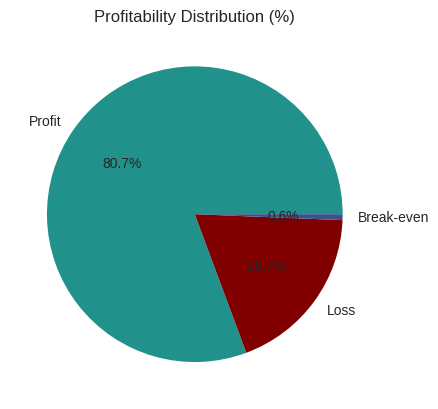

In [22]:
# visualisation of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct= '%1.1f%%', colors = [accent_color,danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [23]:
def format_func(value):
  if value >= 1e6:
    return f'{value/1e6:.1f}M $'
  elif value >= 1e3:
    return f'{value/1e3:.1f}K $'
  else:
    return f'{value:.0f} $'

delayed_df = df[df['Delay']>0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Dealy(days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1- float(metrics['Late Deliveries'])/ metrics['Total Orders'])*100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] *100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] >0, 'Order Profit Per Order'].sum())
metrics['Total Loass due to delays'] = format_func(df.loc[df['Delay'] >0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
  if isinstance(v, float):
    print(f"{k}: {v: .2f}")
  else:
    print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 129519
Late Deliveries: 71447
90% Dealy(days):  3.00
On time Delivery %:  44.84
Late Delivery %:  55.16
Total Profit: 5.3M $
Total Loass due to delays: 1.5M $


# Profitability vs Delivery Time Analysis

In [24]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    )
    .reset_index()
)

In [25]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2.0,22.438720,342796.319934,15277
1,-1.0,20.356202,308803.580173,15170
2,0.0,21.110899,583167.470399,27624
3,1.0,21.201696,845820.470575,39894
4,2.0,20.121826,418292.519651,20788
5,3.0,17.266400,92910.499882,5381
6,4.0,20.392078,109790.949936,5384


In [26]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize =True)
    .sort_index() * 100
).reset_index()

In [28]:
delay_distribution

,Delay,proportion
0,-2.0,11.795272
1,-1.0,11.712658
2,0.0,21.328310
3,1.0,30.801896
4,2.0,16.050279
5,3.0,4.154635
6,4.0,4.156951



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2.0,22.4,342796.3,15277
1,-1.0,20.4,308803.6,15170
2,0.0,21.1,583167.5,27624
3,1.0,21.2,845820.5,39894
4,2.0,20.1,418292.5,20788
5,3.0,17.3,92910.5,5381
6,4.0,20.4,109790.9,5384



Delay Distribution (%):


,Delay_Days,Percentage
0,-2.0,11.795272
1,-1.0,11.712658
2,0.0,21.328310
3,1.0,30.801896
4,2.0,16.050279
5,3.0,4.154635
6,4.0,4.156951


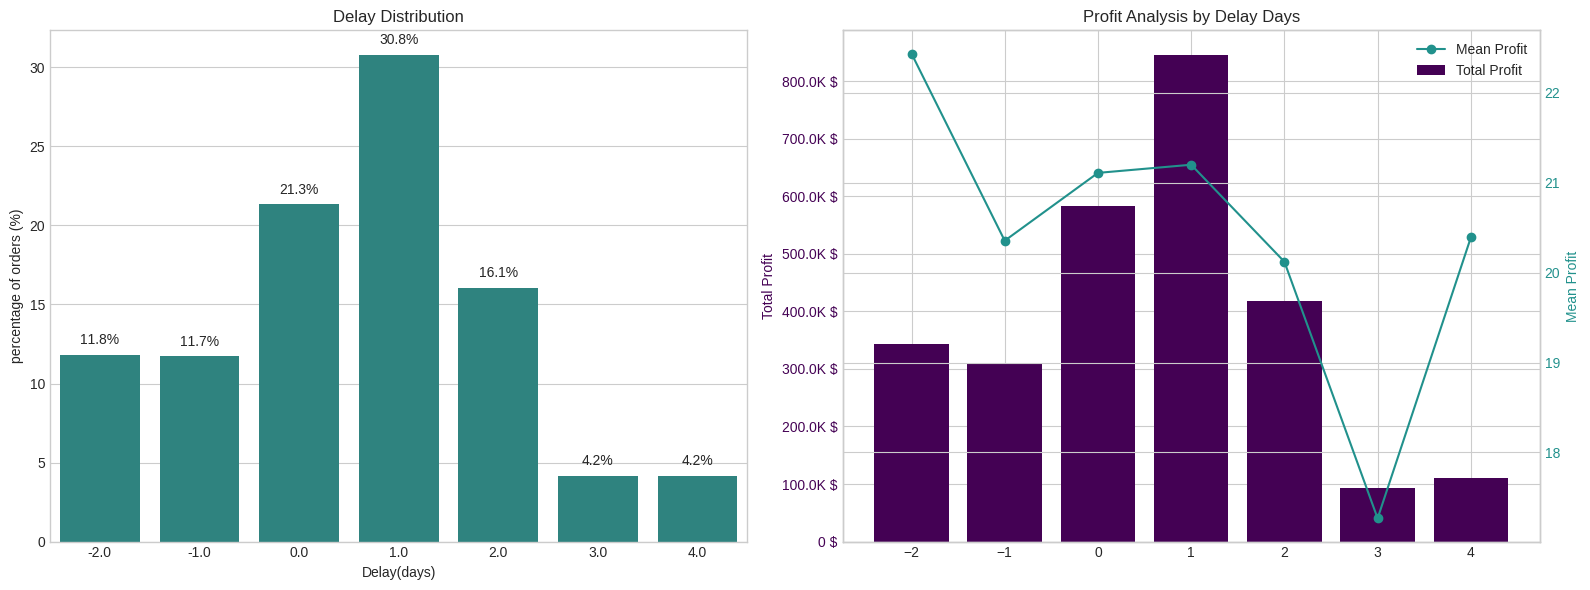

In [29]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))

# First subplot: Delay Distribution
sns.barplot(x= 'Delay_Days', y= 'Percentage', data= delay_distribution, color=accent_color, ax= ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay(days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
  height = bar.get_height()
  ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va = 'bottom')

# Second subplot: Profit Analysis by Delay days
ax2.set_ylabel("Total Profit", color = primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color = primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker ='o', label = 'Mean Profit', color = accent_color )
ax3.tick_params(axis='y', labelcolor=accent_color)

# format total profit axis to K $, M $
def format_func(value, tick_number):
  if value >= 1e6:
    return f'{value/1e6:.1f}M $'
  elif value >= 1e3:
    return f'{value/1e3:.1f}K $'
  else:
    return f'{value:.0f} $'
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc = 'upper right')

plt.tight_layout()
plt.show()


# Bottleneck Detection


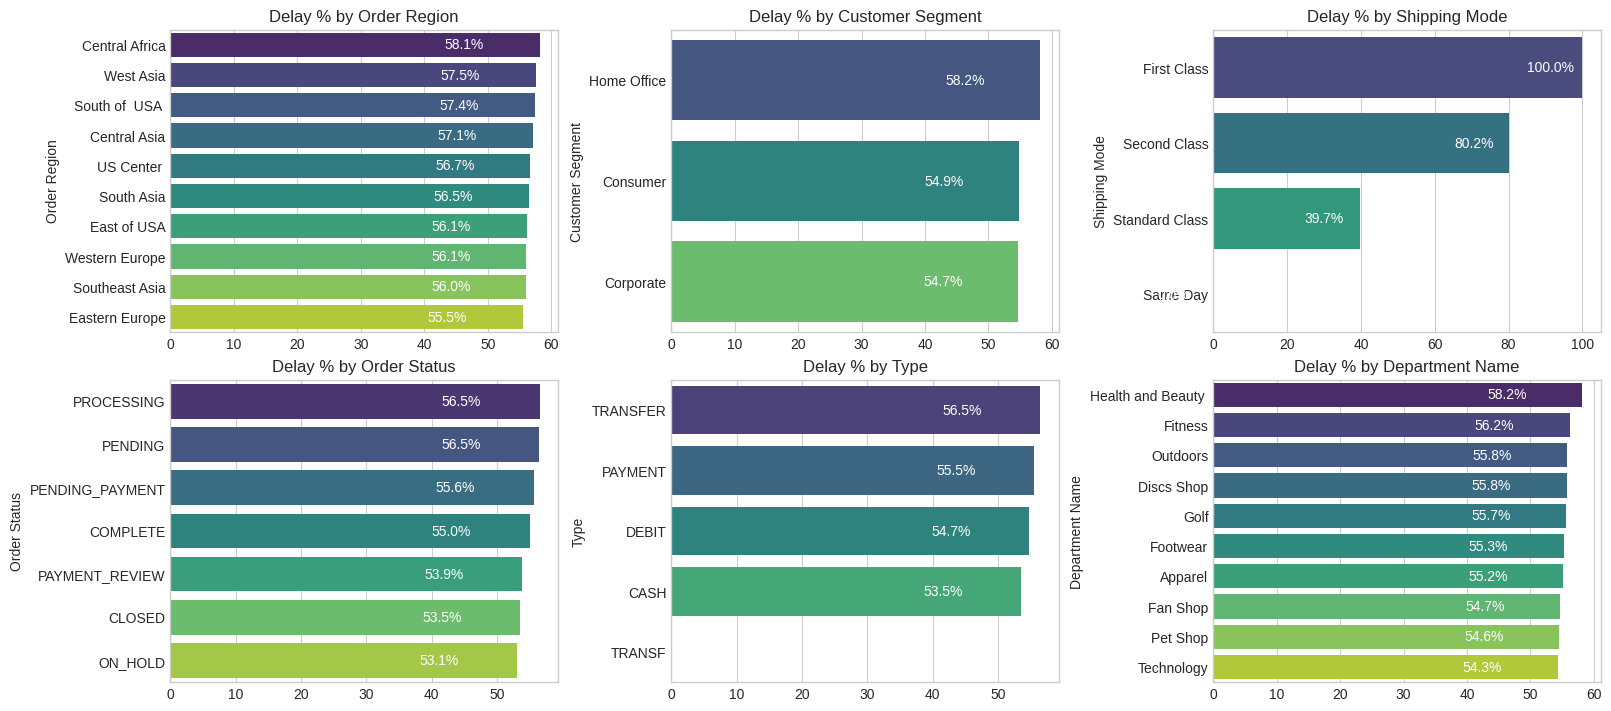

In [30]:
def compute_delay_pct_by_category(category):
  cat_df = df.groupby(category).agg(
      total_orders = ('Delay', 'count'),
      late_orders = ('Is_Delayed', 'sum')
  ).reset_index()
  cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
  cat_df = cat_df.sort_values('delay_pct', ascending = False).head(10)
  return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16,7), constrained_layout= True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
  cat_df = compute_delay_pct_by_category(category)
  sns.barplot(
      data = cat_df,
      x = 'delay_pct',
      y = category,
      ax = ax,
      palette='viridis'
  )
  ax.set_title(f'Delay % by {category}')
  ax.set_xlabel('')
  ax.set_ylabel(category)
  for i, row in cat_df.reset_index().iterrows():
    ax.text(row['delay_pct'] -15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color='white')

plt.show()

# Root Cause Analysis

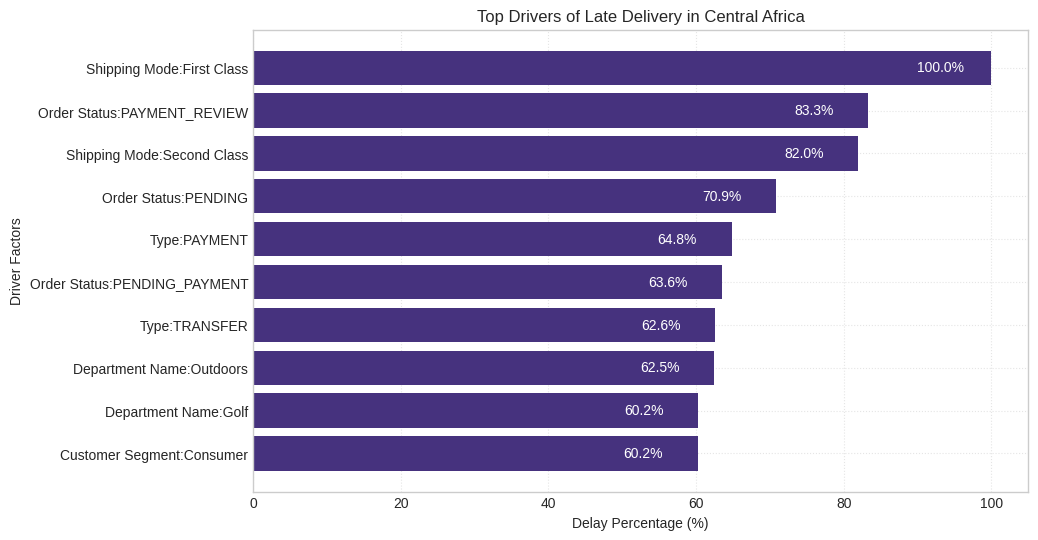

In [31]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
  df_region = df[df['Order Region'] == region].copy()

  drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

  all_factors = []
  for factor in drivers:
    temp = (
        df_region.groupby(factor)
        .agg(
            total_orders=('Delay', 'count'),
            late_orders=('Is_Delayed', 'sum'),
            avg_delay=('Delay', 'mean')
        )
        .reset_index()
    )
    temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
    temp['Driver'] = factor
    temp['Factor_level'] = factor + ":" + temp[factor].astype(str)

    all_factors.append(temp[['Driver', 'Factor_level', 'delay_pct', 'avg_delay', 'total_orders']])

  # Combine all drivers
  final_df = pd.concat(all_factors)

  # Top 10 drivers
  top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
  plt.figure(figsize=(10, 6))

  bars = plt.barh(top_factors['Factor_level'], top_factors['delay_pct'])

  plt.xlabel("Delay Percentage (%)")
  plt.ylabel("Driver Factors")
  plt.title(f"Top Drivers of Late Delivery in {region}")
  plt.grid(True, linestyle=':', alpha=0.5)
  plt.gca().invert_yaxis()
  for bar in bars:
    width = bar.get_width()
    plt.text(width -10, bar.get_y()+ bar.get_height()/2,
             f"{width:.1f}%",
             va='center', fontsize = 10, color = 'white')
  plt.show()


top_drivers_for_region('Central Africa')

# TIME BASED ANALYSIS

In [36]:
# Delay % by month, day of week, hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

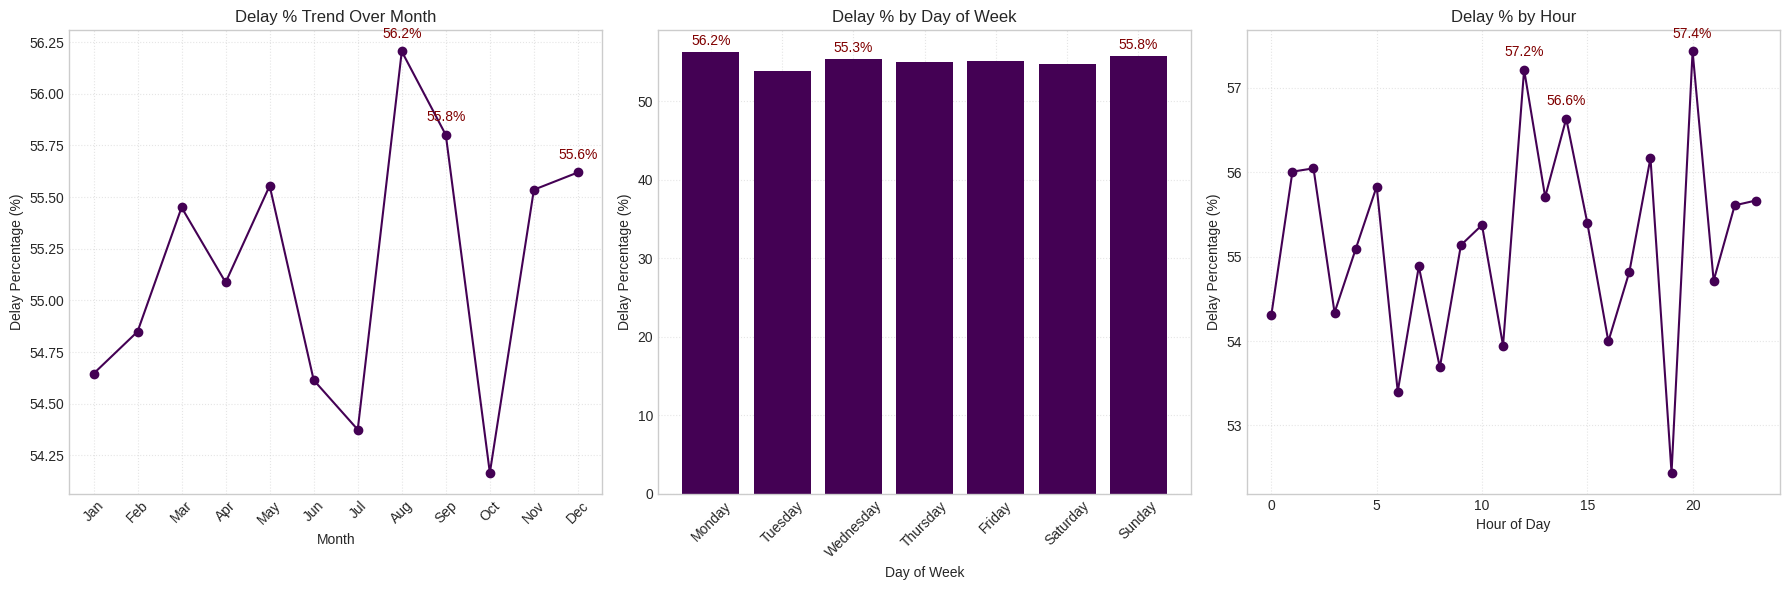

In [37]:
from matplotlib.typing import MarkerType
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(18, 6))

# subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker ='o', color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan', 'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

#Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
  ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
               textcoords="offset points", xytext=(0, 10), ha='center', fontsize = 10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day']= pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
  height = row['delay_pct']
  ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)


# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker ='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 Highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
  ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
               textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)


plt.tight_layout()
plt.show()


